# SAR Vehicle Classifier (MSTAR) — Modern ViT Backbone Comparison + Final Model

Your previous run hit **98.6% test accuracy / 0.982 macro F1** with `vit_small_patch16_224.augreg_in21k_ft_in1k`
— an excellent, near-literature-SOTA result for MSTAR under full supervision (this benchmark is
famously close to solved). That backbone is a strong, standard 2021 recipe, but not the newest.

Two upgrades in this version, aimed at making this a genuinely solid "ViT experience" rather
than a single hardcoded model:

1. **A real backbone comparison.** Instead of just trusting one default, this notebook quickly
   screens a few modern ViT variants on the same data and recipe, then does a full training run
   on whichever one actually wins — an evidence-based choice, not a guess:
   - `vit_small_patch16_224.augreg_in21k_ft_in1k` — the 2021 "AugReg" recipe (your previous run)
   - `deit3_small_patch16_224.fb_in22k_ft_in1k` — Meta's 2022 improved ViT training recipe
   - `eva02_small_patch14_224.mim_in22k` — a 2023 recipe, currently one of the strongest small
     ViT backbones in `timm`, pretrained via masked image modeling + CLIP distillation
2. **A proper train / validation / test split.** The previous version selected its "best epoch"
   checkpoint using *test* accuracy, then reported that same test accuracy as the final number —
   a common shortcut, but not rigorous (you're partly selecting on the data you're reporting on).
   This version carves a validation set out of the training data for checkpoint selection and
   backbone screening, and only touches the test set once, at the very end, for final reporting.


In [1]:
# Colab: uncomment to install (timm is not preinstalled)
# !pip install timm -q

import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU in Colab for a usable speed.")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Data ----
DATA_DIR = "/kaggle/input/datasets/ravenchencn/mstar-10-classes/MSTAR-10-Classes"
EXPECTED_CLASSES = ['2S1', 'BMP2', 'BRDM2', 'BTR60', 'BTR70', 'D7', 'SLICY', 'T62', 'T72',
                     'ZIL131', 'ZSU_23_4']
EXCLUDE_CLASSES = ['SLICY']   # calibration target, not a vehicle -- excluded from the task
VAL_FRACTION = 0.15           # carved out of TRAIN only -- test stays fully held out until the end

# ---- Backbones to compare ----
# Each is a legitimate "modern ViT" choice; comparing them (instead of picking one on faith) is
# the point of this notebook. If a backbone fails to load (timm version mismatch, no internet
# for that specific checkpoint, incompatible patch size for the current IMG_SIZE), it's skipped
# with a clear message rather than crashing the whole comparison.
CANDIDATE_BACKBONES = [
    'vit_small_patch16_224.augreg_in21k_ft_in1k',   # 2021 AugReg recipe -- your previous run
    'deit3_small_patch16_224.fb_in22k_ft_in1k',      # 2022 DeiT III recipe
    'eva02_small_patch14_224.mim_in22k',             # 2023 recipe, currently one of timm's strongest small ViTs
]

IMG_SIZE = 224 if device == 'cuda' else 128   # native res for the checkpoints above, on GPU

# ---- Training ----
SCREEN_EPOCHS = 6     # quick, cheap comparison run per backbone -- enough to separate them
FULL_EPOCHS = 20      # full training run on the winning backbone
BATCH_SIZE = 64 if device == 'cuda' else 16
LR = 3e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 2
LABEL_SMOOTHING = 0.1
USE_AMP = (device == 'cuda')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)


Device: cuda
GPU: Tesla T4


## 1. Load the data, with a real train/val/test split

Same real MSTAR structure as before. New: a stratified validation split is carved out of
`train/` (15% per class) so backbone screening and checkpoint selection never look at the test
set. Test stays untouched until the final evaluation cell.

Excluded classes ['SLICY']: 5744 -> 5172 chips
Confirmed real MSTAR data at '/kaggle/input/datasets/ravenchencn/mstar-10-classes/MSTAR-10-Classes'
Classes (10): ['2S1', 'BMP2', 'BRDM2', 'BTR60', 'BTR70', 'D7', 'T62', 'T72', 'ZIL131', 'ZSU_23_4']
Train: 2334   Val: 413 (held out from train, for model selection)   Test: 2425 (untouched until final evaluation)


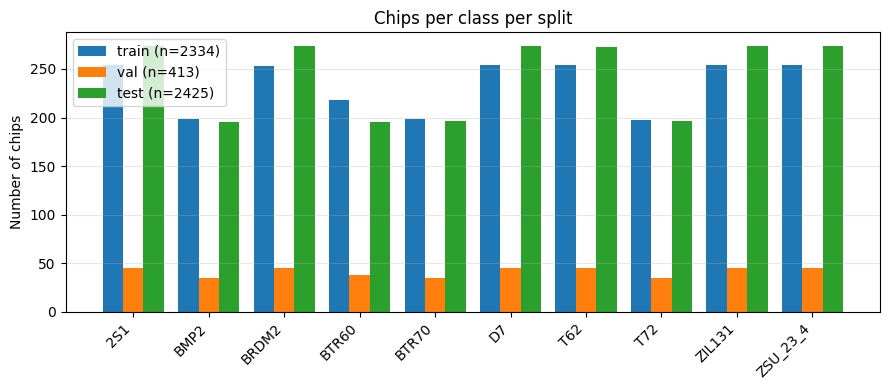

In [2]:
def discover_dataset(root, extensions=('.jpg', '.jpeg', '.png')):
    records = []
    if not os.path.isdir(root):
        return records
    for split in sorted(os.listdir(root)):
        split_path = os.path.join(root, split)
        if not os.path.isdir(split_path):
            continue
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if not os.path.isdir(cls_path):
                continue
            for fname in sorted(os.listdir(cls_path)):
                if fname.lower().endswith(extensions):
                    records.append({'path': os.path.join(cls_path, fname), 'class': cls, 'split': split})
    return records


def find_dataset_root(path, max_up=3, max_down=2):
    path = os.path.normpath(path)
    if os.path.isdir(path):
        recs = discover_dataset(path)
        if recs:
            return path, recs
    p = path
    for _ in range(max_up):
        parent = os.path.dirname(p)
        if not parent or parent == p or not os.path.isdir(parent):
            break
        recs = discover_dataset(parent)
        if recs:
            return parent, recs
        p = parent

    def _walk_down(base, depth):
        if depth == 0 or not os.path.isdir(base):
            return None
        for name in sorted(os.listdir(base)):
            sub = os.path.join(base, name)
            if not os.path.isdir(sub):
                continue
            recs = discover_dataset(sub)
            if recs:
                return sub, recs
            deeper = _walk_down(sub, depth - 1)
            if deeper:
                return deeper
        return None

    return _walk_down(path, max_down) or (None, [])


found_root, records = find_dataset_root(DATA_DIR)
if not records:
    raise FileNotFoundError(
        f"No data found under or near '{DATA_DIR}'. Check DATA_DIR points at the folder that "
        f"directly contains train/ and test/.")
DATA_DIR = found_root

if EXCLUDE_CLASSES:
    before = len(records)
    records = [r for r in records if r['class'] not in EXCLUDE_CLASSES]
    print(f"Excluded classes {EXCLUDE_CLASSES}: {before} -> {len(records)} chips")

classes = sorted(set(r['class'] for r in records))
class_to_idx = {c: i for i, c in enumerate(classes)}
all_train_records = [r for r in records if r['split'] == 'train']
test_records = [r for r in records if r['split'] == 'test']

# Stratified train/val split -- per class, so every class is represented in val proportionally
rng = np.random.default_rng(SEED)
by_class = {}
for r in all_train_records:
    by_class.setdefault(r['class'], []).append(r)

train_records, val_records = [], []
for cls, items in by_class.items():
    idx = rng.permutation(len(items))
    n_val = max(1, int(round(len(items) * VAL_FRACTION)))
    val_idx, train_idx = set(idx[:n_val]), set(idx[n_val:])
    train_records += [items[i] for i in train_idx]
    val_records += [items[i] for i in val_idx]

found_ok = set(EXPECTED_CLASSES) - set(EXCLUDE_CLASSES) <= set(classes)
print(f"{'Confirmed real MSTAR data' if found_ok else 'WARNING: unexpected class set'} at '{DATA_DIR}'")
print(f"Classes ({len(classes)}): {classes}")
print(f"Train: {len(train_records)}   Val: {len(val_records)} (held out from train, for model "
      f"selection)   Test: {len(test_records)} (untouched until final evaluation)")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(classes))
tr_c = [sum(1 for r in train_records if r['class'] == c) for c in classes]
va_c = [sum(1 for r in val_records if r['class'] == c) for c in classes]
te_c = [sum(1 for r in test_records if r['class'] == c) for c in classes]
ax.bar(x - 0.27, tr_c, 0.27, label=f'train (n={sum(tr_c)})')
ax.bar(x, va_c, 0.27, label=f'val (n={sum(va_c)})')
ax.bar(x + 0.27, te_c, 0.27, label=f'test (n={sum(te_c)})')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_ylabel("Number of chips"); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title("Chips per class per split")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, "0_class_counts.png"), dpi=150, bbox_inches="tight")


## 2. Dataset and SAR-appropriate augmentation

Same as before: rotation/flip plus multiplicative speckle noise (the real noise model for
coherent radar imagery), with in-memory caching so repeated epochs don't keep re-decoding files.

In [3]:
def sar_speckle_noise(img, strength=0.3):
    noise = np.random.exponential(1.0, size=img.shape)
    noise = 1 + strength * (noise - 1)
    return np.clip(img.astype(np.float32) * noise, 0, 255).astype(np.uint8)


_IMG_CACHE = {}

def load_gray(path, size):
    key = (path, size)
    arr = _IMG_CACHE.get(key)
    if arr is None:
        arr = np.array(Image.open(path).convert('L').resize((size, size)))
        _IMG_CACHE[key] = arr
    return arr


class ChipDataset(Dataset):
    def __init__(self, records, class_to_idx, img_size, train=False):
        self.records = records
        self.class_to_idx = class_to_idx
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = load_gray(rec['path'], self.img_size)
        if self.train:
            img = np.rot90(img, np.random.randint(0, 4)).copy()
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()
            img = sar_speckle_noise(img, strength=np.random.uniform(0.05, 0.25))
        img = img.astype(np.float32) / 255.0
        x = torch.from_numpy(img).unsqueeze(0)
        y = self.class_to_idx[rec['class']]
        return x, y


NUM_WORKERS = min(4, os.cpu_count() or 0) if device == 'cuda' else 0
train_ds = ChipDataset(train_records, class_to_idx, IMG_SIZE, train=True)
val_ds = ChipDataset(val_records, class_to_idx, IMG_SIZE, train=False)
test_ds = ChipDataset(test_records, class_to_idx, IMG_SIZE, train=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=NUM_WORKERS)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=NUM_WORKERS)
print(f"Train batches: {len(train_dl)}   Val batches: {len(val_dl)}   Test batches: {len(test_dl)}")


Train batches: 36   Val batches: 4   Test batches: 19


## 3. Shared training/evaluation helpers

Used both for the quick backbone screen and the full final training run, so the two are
directly comparable (same optimizer, schedule, and loss).

In [4]:
def build_model(backbone_name, num_classes, img_size):
    return timm.create_model(backbone_name, pretrained=True, num_classes=num_classes,
                              in_chans=1, img_size=img_size)


@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    y_true, y_pred = [], []
    for x, y in dl:
        x = x.to(device)
        with torch.autocast(device_type='cuda', enabled=USE_AMP):
            pred = model(x).argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy()); y_pred.extend(pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, f1, y_true, y_pred


def train_model(model, epochs, train_dl, select_dl):
    """Trains `model`, evaluating on `select_dl` each epoch and keeping the best checkpoint by
    that split's accuracy. `select_dl` should be val_dl for both screening and the final run --
    never test_dl, so the test set stays untouched until the very end."""
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / WARMUP_EPOCHS
        progress = (epoch - WARMUP_EPOCHS) / max(1, epochs - WARMUP_EPOCHS)
        return 0.5 * (1 + np.cos(np.pi * progress))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
    best_acc, best_state = -1, None

    for epoch in range(epochs):
        model.train()
        losses = []
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            with torch.autocast(device_type='cuda', enabled=USE_AMP):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()
            losses.append(loss.item())
        sched.step()

        val_acc, val_f1, _, _ = evaluate(model, select_dl)
        history['train_loss'].append(np.mean(losses))
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  epoch {epoch+1:2d}/{epochs}  train_loss={history['train_loss'][-1]:.3f}  "
              f"val_acc={val_acc:.3f}  val_f1={val_f1:.3f}" + ("  <- best" if val_acc == best_acc else ""))

    model.load_state_dict(best_state)
    return model, best_acc, history


## 4. Backbone comparison (screening run)

A short, cheap training run (`SCREEN_EPOCHS`) for each candidate backbone, selected on the
validation set. This is not each model's best possible accuracy (that comes from the longer
`FULL_EPOCHS` run below) — it's just enough signal to make an evidence-based pick instead of
guessing. Any backbone that fails to load (version mismatch, incompatible patch size for
`IMG_SIZE`, no internet for that specific checkpoint) is skipped with a clear message rather
than crashing the comparison.


=== Screening: vit_small_patch16_224.augreg_in21k_ft_in1k ===


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  epoch  1/6  train_loss=1.847  val_acc=0.700  val_f1=0.674  <- best
  epoch  2/6  train_loss=1.083  val_acc=0.864  val_f1=0.820  <- best
  epoch  3/6  train_loss=0.880  val_acc=0.843  val_f1=0.829
  epoch  4/6  train_loss=0.784  val_acc=0.896  val_f1=0.882  <- best
  epoch  5/6  train_loss=0.652  val_acc=0.964  val_f1=0.960  <- best
  epoch  6/6  train_loss=0.562  val_acc=0.969  val_f1=0.964  <- best
  -> val_acc=0.969  params=21.5M  time=49s

=== Screening: deit3_small_patch16_224.fb_in22k_ft_in1k ===


model.safetensors:   0%|          | 0.00/88.3M [00:00<?, ?B/s]

  epoch  1/6  train_loss=1.736  val_acc=0.753  val_f1=0.695  <- best
  epoch  2/6  train_loss=1.258  val_acc=0.748  val_f1=0.698
  epoch  3/6  train_loss=0.854  val_acc=0.932  val_f1=0.917  <- best
  epoch  4/6  train_loss=0.727  val_acc=0.927  val_f1=0.910
  epoch  5/6  train_loss=0.641  val_acc=0.961  val_f1=0.958  <- best
  epoch  6/6  train_loss=0.550  val_acc=0.983  val_f1=0.981  <- best
  -> val_acc=0.983  params=21.5M  time=55s

=== Screening: eva02_small_patch14_224.mim_in22k ===


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

  epoch  1/6  train_loss=2.124  val_acc=0.283  val_f1=0.179  <- best
  epoch  2/6  train_loss=1.904  val_acc=0.138  val_f1=0.068
  epoch  3/6  train_loss=1.800  val_acc=0.433  val_f1=0.306  <- best
  epoch  4/6  train_loss=1.624  val_acc=0.315  val_f1=0.239
  epoch  5/6  train_loss=1.388  val_acc=0.475  val_f1=0.376  <- best
  epoch  6/6  train_loss=1.231  val_acc=0.557  val_f1=0.488  <- best
  -> val_acc=0.557  params=21.5M  time=97s

--- Screening results (sorted by validation accuracy) ---
  deit3_small_patch16_224.fb_in22k_ft_in1k            val_acc=0.983   21.5M params     55s
  vit_small_patch16_224.augreg_in21k_ft_in1k          val_acc=0.969   21.5M params     49s
  eva02_small_patch14_224.mim_in22k                   val_acc=0.557   21.5M params     97s


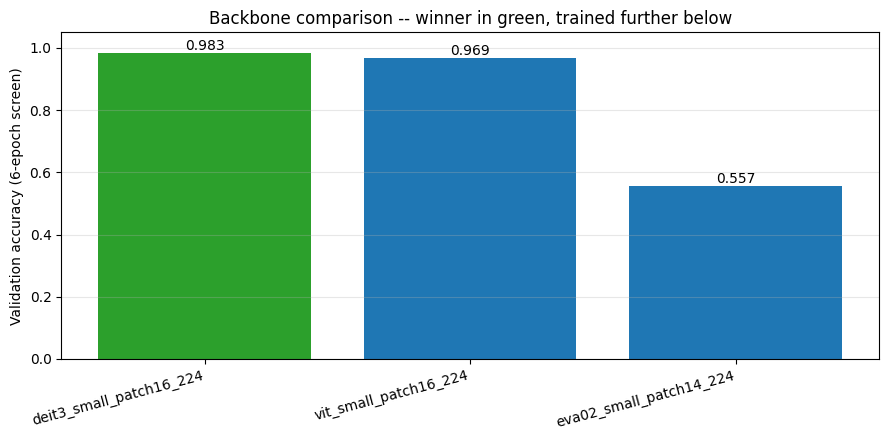


Winning backbone: deit3_small_patch16_224.fb_in22k_ft_in1k


In [5]:
screen_results = []

for backbone_name in CANDIDATE_BACKBONES:
    print(f"\n=== Screening: {backbone_name} ===")
    try:
        model = build_model(backbone_name, len(classes), IMG_SIZE)
    except Exception as e:
        print(f"  SKIPPED -- could not build this backbone: {e}")
        continue

    n_params = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    model, val_acc, _ = train_model(model, SCREEN_EPOCHS, train_dl, val_dl)
    elapsed = time.time() - t0

    screen_results.append(dict(backbone=backbone_name, val_acc=val_acc, params_m=n_params/1e6,
                                seconds=elapsed))
    print(f"  -> val_acc={val_acc:.3f}  params={n_params/1e6:.1f}M  time={elapsed:.0f}s")
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()

if not screen_results:
    raise RuntimeError("No candidate backbone could be built -- check timm version / internet access.")

screen_results.sort(key=lambda r: -r['val_acc'])
print("\n--- Screening results (sorted by validation accuracy) ---")
for r in screen_results:
    print(f"  {r['backbone']:50s}  val_acc={r['val_acc']:.3f}  {r['params_m']:5.1f}M params  {r['seconds']:5.0f}s")

fig, ax = plt.subplots(figsize=(9, 4.5))
names = [r['backbone'].split('.')[0] for r in screen_results]
accs = [r['val_acc'] for r in screen_results]
bars = ax.bar(names, accs, color=['tab:green' if r is screen_results[0] else 'tab:blue' for r in screen_results])
for bar, r in zip(bars, screen_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{r['val_acc']:.3f}",
            ha='center', fontsize=10)
ax.set_ylabel(f"Validation accuracy ({SCREEN_EPOCHS}-epoch screen)")
ax.set_title("Backbone comparison -- winner in green, trained further below")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, "1_backbone_comparison.png"), dpi=150, bbox_inches="tight")

BEST_BACKBONE = screen_results[0]['backbone']
print(f"\nWinning backbone: {BEST_BACKBONE}")


## 5. Full training on the winning backbone

Same recipe, run to completion (`FULL_EPOCHS`), still model-selected on validation accuracy —
the test set has not been touched by anything above this point.

Training deit3_small_patch16_224.fb_in22k_ft_in1k for 20 epochs...
Parameters: 21.5M   Input: 224x224, 1 channel   Classes: 10
  epoch  1/20  train_loss=1.817  val_acc=0.671  val_f1=0.640  <- best
  epoch  2/20  train_loss=1.209  val_acc=0.792  val_f1=0.749  <- best
  epoch  3/20  train_loss=0.901  val_acc=0.869  val_f1=0.859  <- best
  epoch  4/20  train_loss=0.825  val_acc=0.927  val_f1=0.919  <- best
  epoch  5/20  train_loss=0.706  val_acc=0.879  val_f1=0.858
  epoch  6/20  train_loss=0.726  val_acc=0.915  val_f1=0.903
  epoch  7/20  train_loss=0.652  val_acc=0.932  val_f1=0.928  <- best
  epoch  8/20  train_loss=0.607  val_acc=0.925  val_f1=0.916
  epoch  9/20  train_loss=0.629  val_acc=0.937  val_f1=0.929  <- best
  epoch 10/20  train_loss=0.594  val_acc=0.961  val_f1=0.956  <- best
  epoch 11/20  train_loss=0.555  val_acc=0.964  val_f1=0.960  <- best
  epoch 12/20  train_loss=0.544  val_acc=0.983  val_f1=0.982  <- best
  epoch 13/20  train_loss=0.540  val_acc=0.990  val_f1=0.990

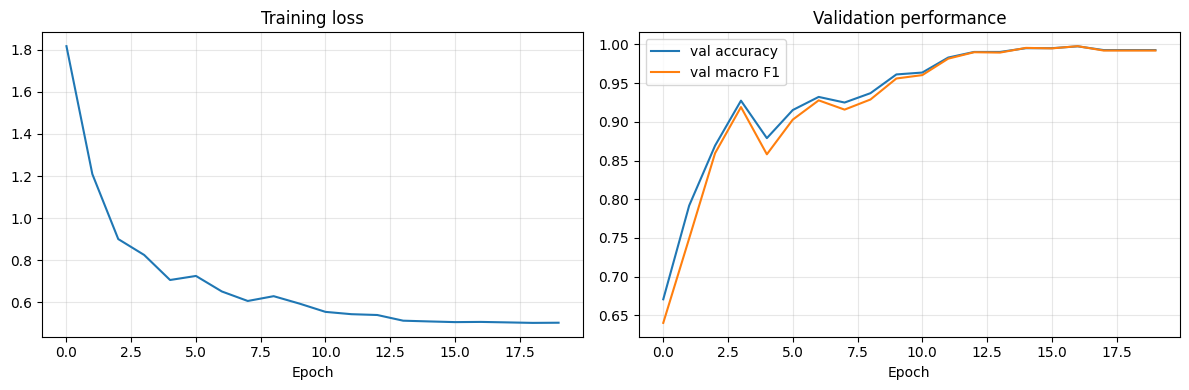

In [6]:
print(f"Training {BEST_BACKBONE} for {FULL_EPOCHS} epochs...")
model = build_model(BEST_BACKBONE, len(classes), IMG_SIZE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params/1e6:.1f}M   Input: {IMG_SIZE}x{IMG_SIZE}, 1 channel   Classes: {len(classes)}")

model, best_val_acc, history = train_model(model, FULL_EPOCHS, train_dl, val_dl)
print(f"\nBest validation accuracy during training: {best_val_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss']); axes[0].set_title("Training loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(history['val_acc'], label='val accuracy'); axes[1].plot(history['val_f1'], label='val macro F1')
axes[1].set_title("Validation performance"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, "2_training_curves.png"), dpi=150, bbox_inches="tight")


## 6. Final evaluation on the held-out test set

The first and only time the test set is used. This is the honest, unbiased number for the
winning model.

Backbone: deit3_small_patch16_224.fb_in22k_ft_in1k
Final TEST accuracy: 0.992   Macro F1: 0.991

              precision    recall  f1-score   support

         2S1      0.996     1.000     0.998       274
        BMP2      1.000     0.933     0.966       195
       BRDM2      1.000     1.000     1.000       274
       BTR60      0.995     0.985     0.990       195
       BTR70      0.995     1.000     0.997       196
          D7      0.996     0.993     0.995       274
         T62      0.996     0.996     0.996       273
         T72      0.933     1.000     0.966       196
      ZIL131      1.000     1.000     1.000       274
    ZSU_23_4      1.000     1.000     1.000       274

    accuracy                          0.992      2425
   macro avg      0.991     0.991     0.991      2425
weighted avg      0.993     0.992     0.992      2425



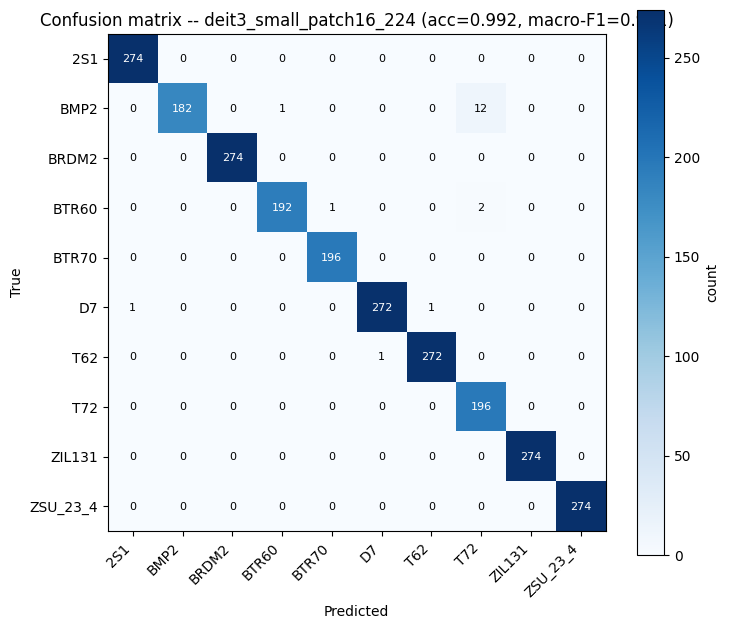

In [7]:
acc, f1, y_true, y_pred = evaluate(model, test_dl)
print(f"Backbone: {BEST_BACKBONE}")
print(f"Final TEST accuracy: {acc:.3f}   Macro F1: {f1:.3f}\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

conf_mat = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(conf_mat, cmap=plt.cm.Blues)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix -- {BEST_BACKBONE.split('.')[0]} (acc={acc:.3f}, macro-F1={f1:.3f})")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, conf_mat[i, j], ha='center', va='center',
                color='white' if conf_mat[i, j] > conf_mat.max()/2 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, label="count")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, "3_confusion_matrix.png"), dpi=150, bbox_inches="tight")


## 7. Prediction gallery

Real test chips, true vs. predicted label, correct in green and wrong in red -- zoomed toward
the center and shown as large tiles so the vehicle itself is easy to see.

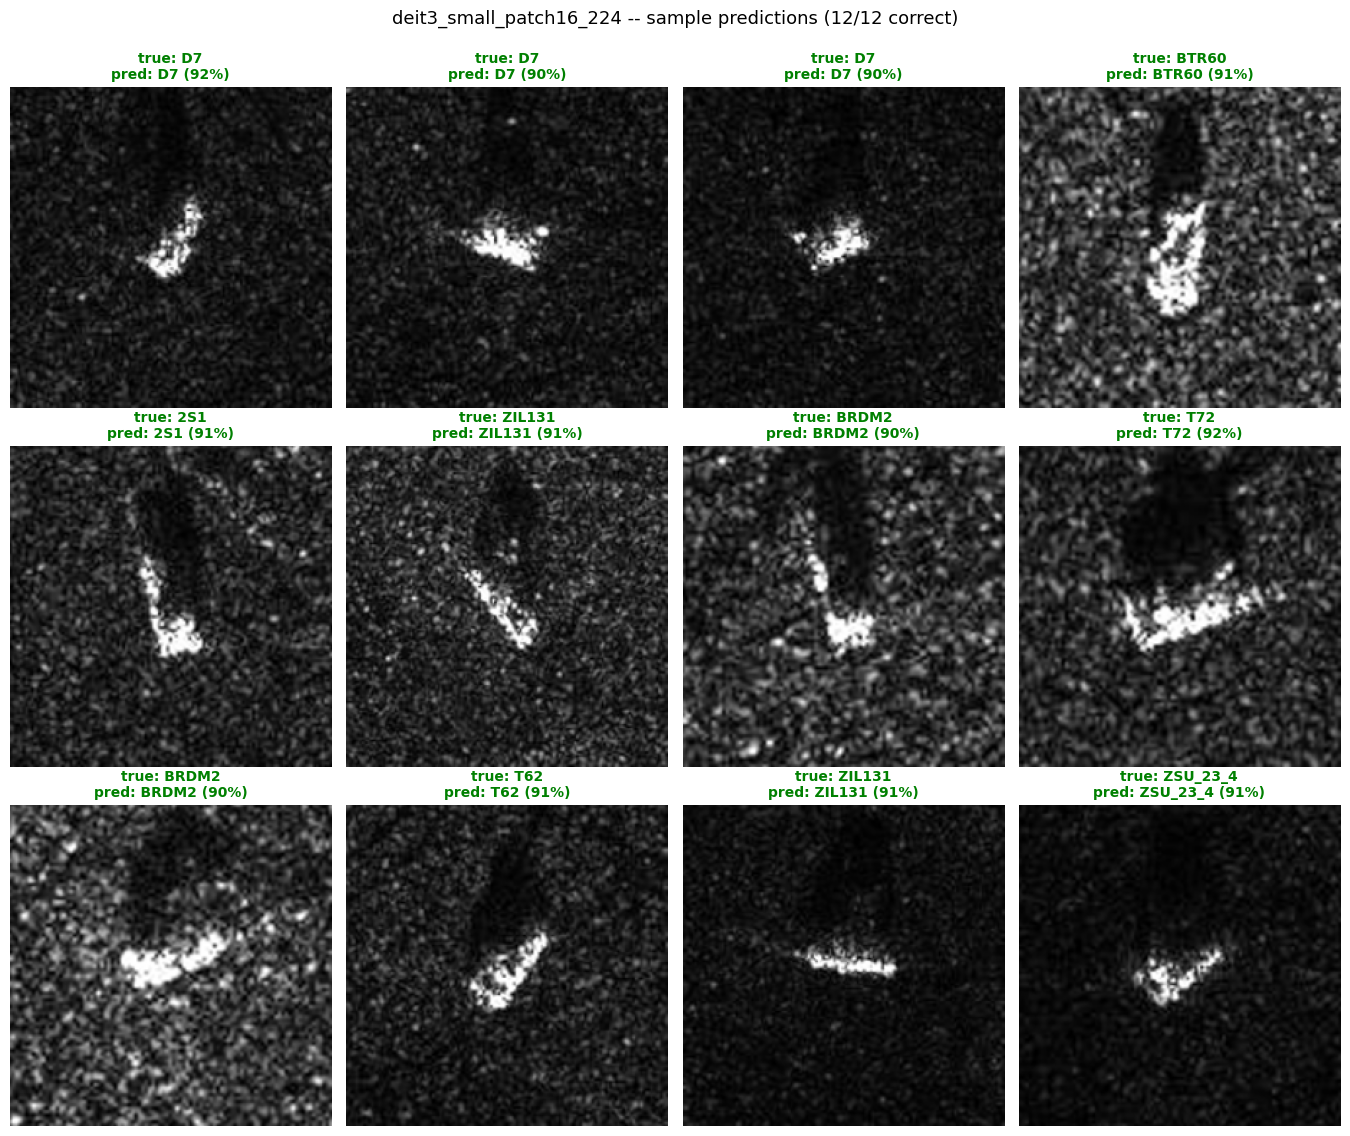

In [8]:
def zoom_crop(img, zoom=1.35):
    h, w = img.shape
    ch, cw = int(h / zoom), int(w / zoom)
    top, left = (h - ch) // 2, (w - cw) // 2
    cropped = img[top:top+ch, left:left+cw]
    return np.array(Image.fromarray(cropped).resize((w, h), Image.BICUBIC))


N_GALLERY = 12
N_COLS = 4
rng = np.random.default_rng(0)
gallery_records = list(test_records)
rng.shuffle(gallery_records)
gallery_records = gallery_records[:N_GALLERY]

n_rows = int(np.ceil(N_GALLERY / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3.4*N_COLS, 3.8*n_rows))
axes = np.array(axes).reshape(n_rows, N_COLS)

model.eval()
n_correct = 0
with torch.no_grad():
    for idx, rec in enumerate(gallery_records):
        r, c = divmod(idx, N_COLS)
        ax = axes[r, c]
        raw = load_gray(rec['path'], IMG_SIZE)
        x = torch.from_numpy(raw.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)
        with torch.autocast(device_type='cuda', enabled=USE_AMP):
            logits = model(x)
        probs = F.softmax(logits, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_cls, true_cls, confidence = classes[pred_idx], rec['class'], probs[pred_idx].item()
        correct = pred_cls == true_cls
        n_correct += correct

        ax.imshow(zoom_crop(raw), cmap='gray')
        ax.set_title(f"true: {true_cls}\npred: {pred_cls} ({confidence:.0%})", fontsize=10,
                     color='green' if correct else 'red', fontweight='bold')
        ax.axis('off')

for idx in range(N_GALLERY, n_rows * N_COLS):
    r, c = divmod(idx, N_COLS)
    axes[r, c].axis('off')

fig.suptitle(f"{BEST_BACKBONE.split('.')[0]} -- sample predictions ({n_correct}/{N_GALLERY} correct)", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, "4_prediction_gallery.png"), dpi=150, bbox_inches="tight")


## Notes

- **Model checkpoint**: `model` in memory holds the best-validation-accuracy weights for
  `BEST_BACKBONE`. Save with
  `torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "vit_mstar_best.pt"))`.
- **Why the winner might not be EVA-02**: newer/larger recipes aren't automatically better on
  every dataset -- on a training set this size (~2,300 images after the val split), a heavier
  or more data-hungry pretraining recipe can *underperform* a lighter one if it overfits faster
  or needs more fine-tuning steps to adapt. That's exactly why this notebook measures it instead
  of assuming it from the model's release date.
- **If you want to push further as a portfolio piece**:
  - Add `DINOv2` (`vit_small_patch14_dinov2.lvd142m`) to `CANDIDATE_BACKBONES` -- a genuinely
    different lineage (self-supervised, not supervised ImageNet pretraining), often excellent on
    transfer tasks outside natural photos.
  - Add mixup/cutmix augmentation and compare its effect on the confusion matrix specifically
    for the classes that are already hardest here (check which off-diagonal cells are largest).
  - Run the full comparison 2-3x with different seeds and report mean ± std per backbone --
    a single screening run has some noise, especially on a dataset this size.
  - Try test-time augmentation (average predictions over a few rotations/flips at inference) for
    a small, nearly-free accuracy bump on the final reported number.
